# Analog Pre-Holidays

Forecasts the `PREVIOUSLY_W_HOURS` window immediately before each listed holiday using the standard `AnalogKNN` model (`analog/analog.py`).

Pipeline:
1. Optionally tune the analog hyperparameters with Optuna over historical holiday windows (`tune_analog_pre_holidays_optuna`).
2. Run `run_analog_pre_holidays_batch` over every (target_date, unique_id) pair.
3. A copy of `pre_holiday_demand_mx.csv` named `pre_holiday_demand_mx_AAAA_MM_DD_HH_MM.csv` is written with the rounded integer forecasts overwriting the pre-holiday rows.

In [10]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import analog_holidays.analog.P_analog_pre_holidays as pre_holidays_module
pre_holidays_module = importlib.reload(pre_holidays_module)

from analog_holidays.analog.P_analog_pre_holidays import (
    list_unique_ids,
    load_pre_holiday_source,
    plot_pre_holiday_batch_grid,
    plot_pre_holiday_run,
    run_analog_pre_holidays_batch,
    tune_analog_pre_holidays_optuna,
)

pd.set_option('display.max_rows', 60)
pd.set_option('display.max_columns', 20)

## Parameters

- `SOURCE_PATH`: hourly wide CSV with one column per series plus `<uid>_holiday` flags.
- `PREVIOUSLY_W_HOURS`: how many hours immediately before each holiday's `00:00` are forecast.
- `UNIQUE_IDS`: subset of series to forecast (set to `None` to use every series found in the CSV).
- `TUNE_UNIQUE_ID`: series used by the Optuna tuner (one regional study is enough).

In [11]:
SOURCE_PATH = PROJECT_ROOT / 'analog_holidays' / 'holidays' / 'pre_holiday_demand_mx.csv'

PREVIOUSLY_W_HOURS = 14
SEASON_LENGTH = 24
K = 10
TOL = 0.8
TYPEDIST = 'pearson'
TYPEREG = 'PCR'
N_COMPONENTS = 3

UNIQUE_IDS = None  # None = every value column in the CSV
TUNE_UNIQUE_ID = 'SEN_demand_SIN'

DATE_END = '2024-01-01'
OPTUNA_N_TRIALS = 25
OPTUNA_TIMEOUT_SEC = 900
OPTUNA_MAX_EVAL_DATES = 12
OPTUNA_RANDOM_SEED = 42

In [12]:
TARGET_DATES_2025 = [
    ('2025-01-01', "New Year's Day"),
    ('2025-02-03', 'Constitution Day'),
    ('2025-03-17', "Benito Juarez's Birthday"),
    ('2025-04-17', 'Maundy Thursday'),
    ('2025-04-18', 'Good Friday'),
    ('2025-04-19', 'Holy Saturday'),
    ('2025-05-01', 'Labor Day'),
    ('2025-09-15', 'Independence Eve'),
    ('2025-09-16', 'Independence Day'),
    ('2025-11-17', 'Mexican Revolution Day'),
    ('2025-12-24', 'Christmas Eve'),
    ('2025-12-25', 'Christmas Day'),
    ('2025-12-31', "New Year's Eve"),
    # ===== 2026 =====
    ('2026-01-01', "New Year's Day"),
    ('2026-02-02', 'Constitution Day'),
    ('2026-03-16', "Benito Juarez's Birthday"),
    ('2026-04-02', 'Maundy Thursday'),
    ('2026-04-03', 'Good Friday'),
    ('2026-04-04', 'Holy Saturday'),
    ('2026-05-01', 'Labor Day'),
]

TARGET_DATE = TARGET_DATES_2025[-1][0]

## Available series

Inspect the unique IDs present in the source CSV. Set `UNIQUE_IDS` to a sublist above if only some series should be forecast.

In [13]:
df_source = load_pre_holiday_source(SOURCE_PATH)
available_ids = list_unique_ids(df_source)
print('Series in source:', available_ids)
df_source.head()

Series in source: ['SEN_demand_SIN', 'SEN_demand_CEL', 'SEN_demand_OCC', 'SEN_demand_NOR', 'SEN_demand_PEN', 'SEN_demand_ORI', 'SEN_demand_NES', 'SEN_demand_NTE']


,ds,SEN_demand_SIN,SEN_demand_SIN_holiday,SEN_demand_CEL,SEN_demand_CEL_holiday,SEN_demand_OCC,SEN_demand_OCC_holiday,SEN_demand_NOR,SEN_demand_NOR_holiday,SEN_demand_PEN,SEN_demand_PEN_holiday,SEN_demand_ORI,SEN_demand_ORI_holiday,SEN_demand_NES,SEN_demand_NES_holiday,SEN_demand_NTE,SEN_demand_NTE_holiday
0,2020-01-02 00:00:00,24878.55898,1,5253.72370,1,5514.72012,1,1692.69642,1,1318.83106,1,4850.36126,1,3989.11732,1,2259.10910,1
1,2020-01-02 01:00:00,23313.94064,1,4617.98020,1,5207.16634,1,1628.46097,1,1254.63592,1,4622.52341,1,3811.13385,1,2172.03995,1
2,2020-01-02 02:00:00,22549.69591,1,4499.96714,1,5039.17489,1,1566.35208,1,1198.75196,1,4443.33022,1,3729.55369,1,2072.56593,1
3,2020-01-02 03:00:00,22035.66456,1,4374.76696,1,4920.02551,1,1511.58700,1,1154.79376,1,4335.60018,1,3704.02220,1,2034.86895,1
4,2020-01-02 04:00:00,21564.47956,1,4241.02555,1,4867.66797,1,1466.45705,1,1124.01702,1,4240.72440,1,3623.63396,1,2000.95361,1


## Optuna tuning (optional)

Tunes `AnalogKNN` hyperparameters back-testing on historical holidays for the chosen series.

In [14]:
optuna_result = tune_analog_pre_holidays_optuna(
    unique_id=TUNE_UNIQUE_ID,
    source_path=SOURCE_PATH,
    train_end=DATE_END,
    previously_w_hours=PREVIOUSLY_W_HOURS,
    season_length=SEASON_LENGTH,
    initial_k=K,
    initial_typedist=TYPEDIST,
    initial_typereg=TYPEREG,
    initial_n_components=N_COMPONENTS,
    n_trials=OPTUNA_N_TRIALS,
    timeout_sec=OPTUNA_TIMEOUT_SEC,
    max_eval_dates=OPTUNA_MAX_EVAL_DATES,
    random_seed=OPTUNA_RANDOM_SEED,
)

K = int(optuna_result.best_config['k'])
TYPEDIST = optuna_result.best_config['typedist']
TYPEREG = optuna_result.best_config['typereg']
N_COMPONENTS = int(optuna_result.best_config['n_components'])

print('Hyperparameters updated for the batch run.')
display(optuna_result.summary_df)
optuna_result.fold_metrics_df

Hyperparameters updated for the batch run.


,param,value
0,unique_id,SEN_demand_SIN
1,cutoff_train,2024-01-01
2,previously_w_hours,14
3,eval_dates,12
4,best_mean_mae,736.058802
5,best_mean_mape_pct,2.169
6,K,29
7,TYPEDIST,pearson
8,TYPEREG,PCR
9,N_COMPONENTS,8


,target_date,mae,mape_pct
0,2023-04-06,208.726635,0.529635
1,2023-04-07,875.377123,2.441379
2,2023-04-08,1739.791069,5.545022
3,2023-04-09,74.229237,0.235000
4,2023-05-01,693.137667,2.047123
5,2023-09-16,1568.362886,3.672945
6,2023-11-02,1184.623031,3.384399
7,2023-11-20,367.394218,1.166127
8,2023-12-12,748.880217,2.148314
9,2023-12-24,236.468724,0.760747


## Batch forecast + CSV export

Writes `pre_holiday_demand_mx_AAAA_MM_DD_HH_MM.csv` next to the source CSV with the integer-rounded forecasts overwriting the pre-holiday rows.

In [15]:
batch_result = run_analog_pre_holidays_batch(
    target_dates=TARGET_DATES_2025,
    source_path=SOURCE_PATH,
    unique_ids=UNIQUE_IDS,
    previously_w_hours=PREVIOUSLY_W_HOURS,
    season_length=SEASON_LENGTH,
    k=K,
    tol=TOL,
    n_components=N_COMPONENTS,
    typedist=TYPEDIST,
    typereg=TYPEREG,
)

print(f'Output written to: {batch_result.output_path}')
display(batch_result.results_df.head(20))
batch_result.results_df.groupby('unique_id')[['mae', 'mape_pct']].mean()

Output written to: C:\GIT\analog_holidays\holidays\pre_holiday_demand_mx_2026_05_23_15_02.csv


,target_date,holiday_label,unique_id,fail,error,mae,mape_pct,hours_written
0,2025-01-01,New Year's Day,SEN_demand_SIN,False,None,1508.450523,5.148481,14
1,2025-01-01,New Year's Day,SEN_demand_CEL,False,None,561.228621,9.476941,14
2,2025-01-01,New Year's Day,SEN_demand_OCC,False,None,494.740711,7.246083,14
3,2025-01-01,New Year's Day,SEN_demand_NOR,False,None,77.306118,3.744327,14
4,2025-01-01,New Year's Day,SEN_demand_PEN,False,None,57.761562,3.446791,14
5,2025-01-01,New Year's Day,SEN_demand_ORI,False,None,131.709530,2.270733,14
6,2025-01-01,New Year's Day,SEN_demand_NES,False,None,288.994195,6.506973,14
7,2025-01-01,New Year's Day,SEN_demand_NTE,False,None,93.642124,3.869139,14
8,2025-02-03,Constitution Day,SEN_demand_SIN,False,None,531.886468,1.748394,14
9,2025-02-03,Constitution Day,SEN_demand_CEL,False,None,137.478469,2.181563,14


,mae,mape_pct
unique_id,,
SEN_demand_CEL,206.722055,3.188410
SEN_demand_NES,221.796435,3.634668
SEN_demand_NOR,115.187274,4.032054
SEN_demand_NTE,96.575075,3.275479
SEN_demand_OCC,213.848803,2.821444
SEN_demand_ORI,153.662764,2.420411
SEN_demand_PEN,64.375456,3.769589
SEN_demand_SIN,764.937866,2.276901


## Inspect a single forecast

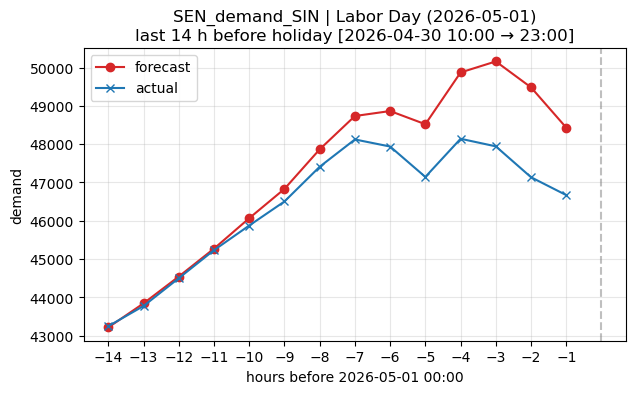

,ds,forecast,forecast_int,actual
0,2026-04-30 10:00:00,43212.310712,43212,43244.0
1,2026-04-30 11:00:00,43840.943008,43841,43772.0
2,2026-04-30 12:00:00,44540.925883,44541,44498.0
3,2026-04-30 13:00:00,45270.059635,45270,45230.0
4,2026-04-30 14:00:00,46065.005649,46065,45874.0
5,2026-04-30 15:00:00,46830.238903,46830,46502.0
6,2026-04-30 16:00:00,47863.888502,47864,47409.0
7,2026-04-30 17:00:00,48734.304169,48734,48122.0
8,2026-04-30 18:00:00,48864.413378,48864,47937.0
9,2026-04-30 19:00:00,48519.994702,48520,47143.0


In [16]:
inspect_uid = (UNIQUE_IDS or available_ids)[0]
run = batch_result.runs.get((TARGET_DATE, inspect_uid))
if run is not None:
    fig, ax = plt.subplots(figsize=(7, 3.8))
    plot_pre_holiday_run(run, ax=ax)
    plt.show()
    df_show = pd.DataFrame({
        'ds': pd.date_range(run.pre_holiday_start, periods=run.previously_w_hours, freq='h'),
        'forecast': run.forecast,
        'forecast_int': run.forecast_int,
        'actual': run.actual if run.actual is not None else np.nan,
    })
    display(df_show)
else:
    print(f'No run found for ({TARGET_DATE}, {inspect_uid}).')

## Grid of forecasts for one series

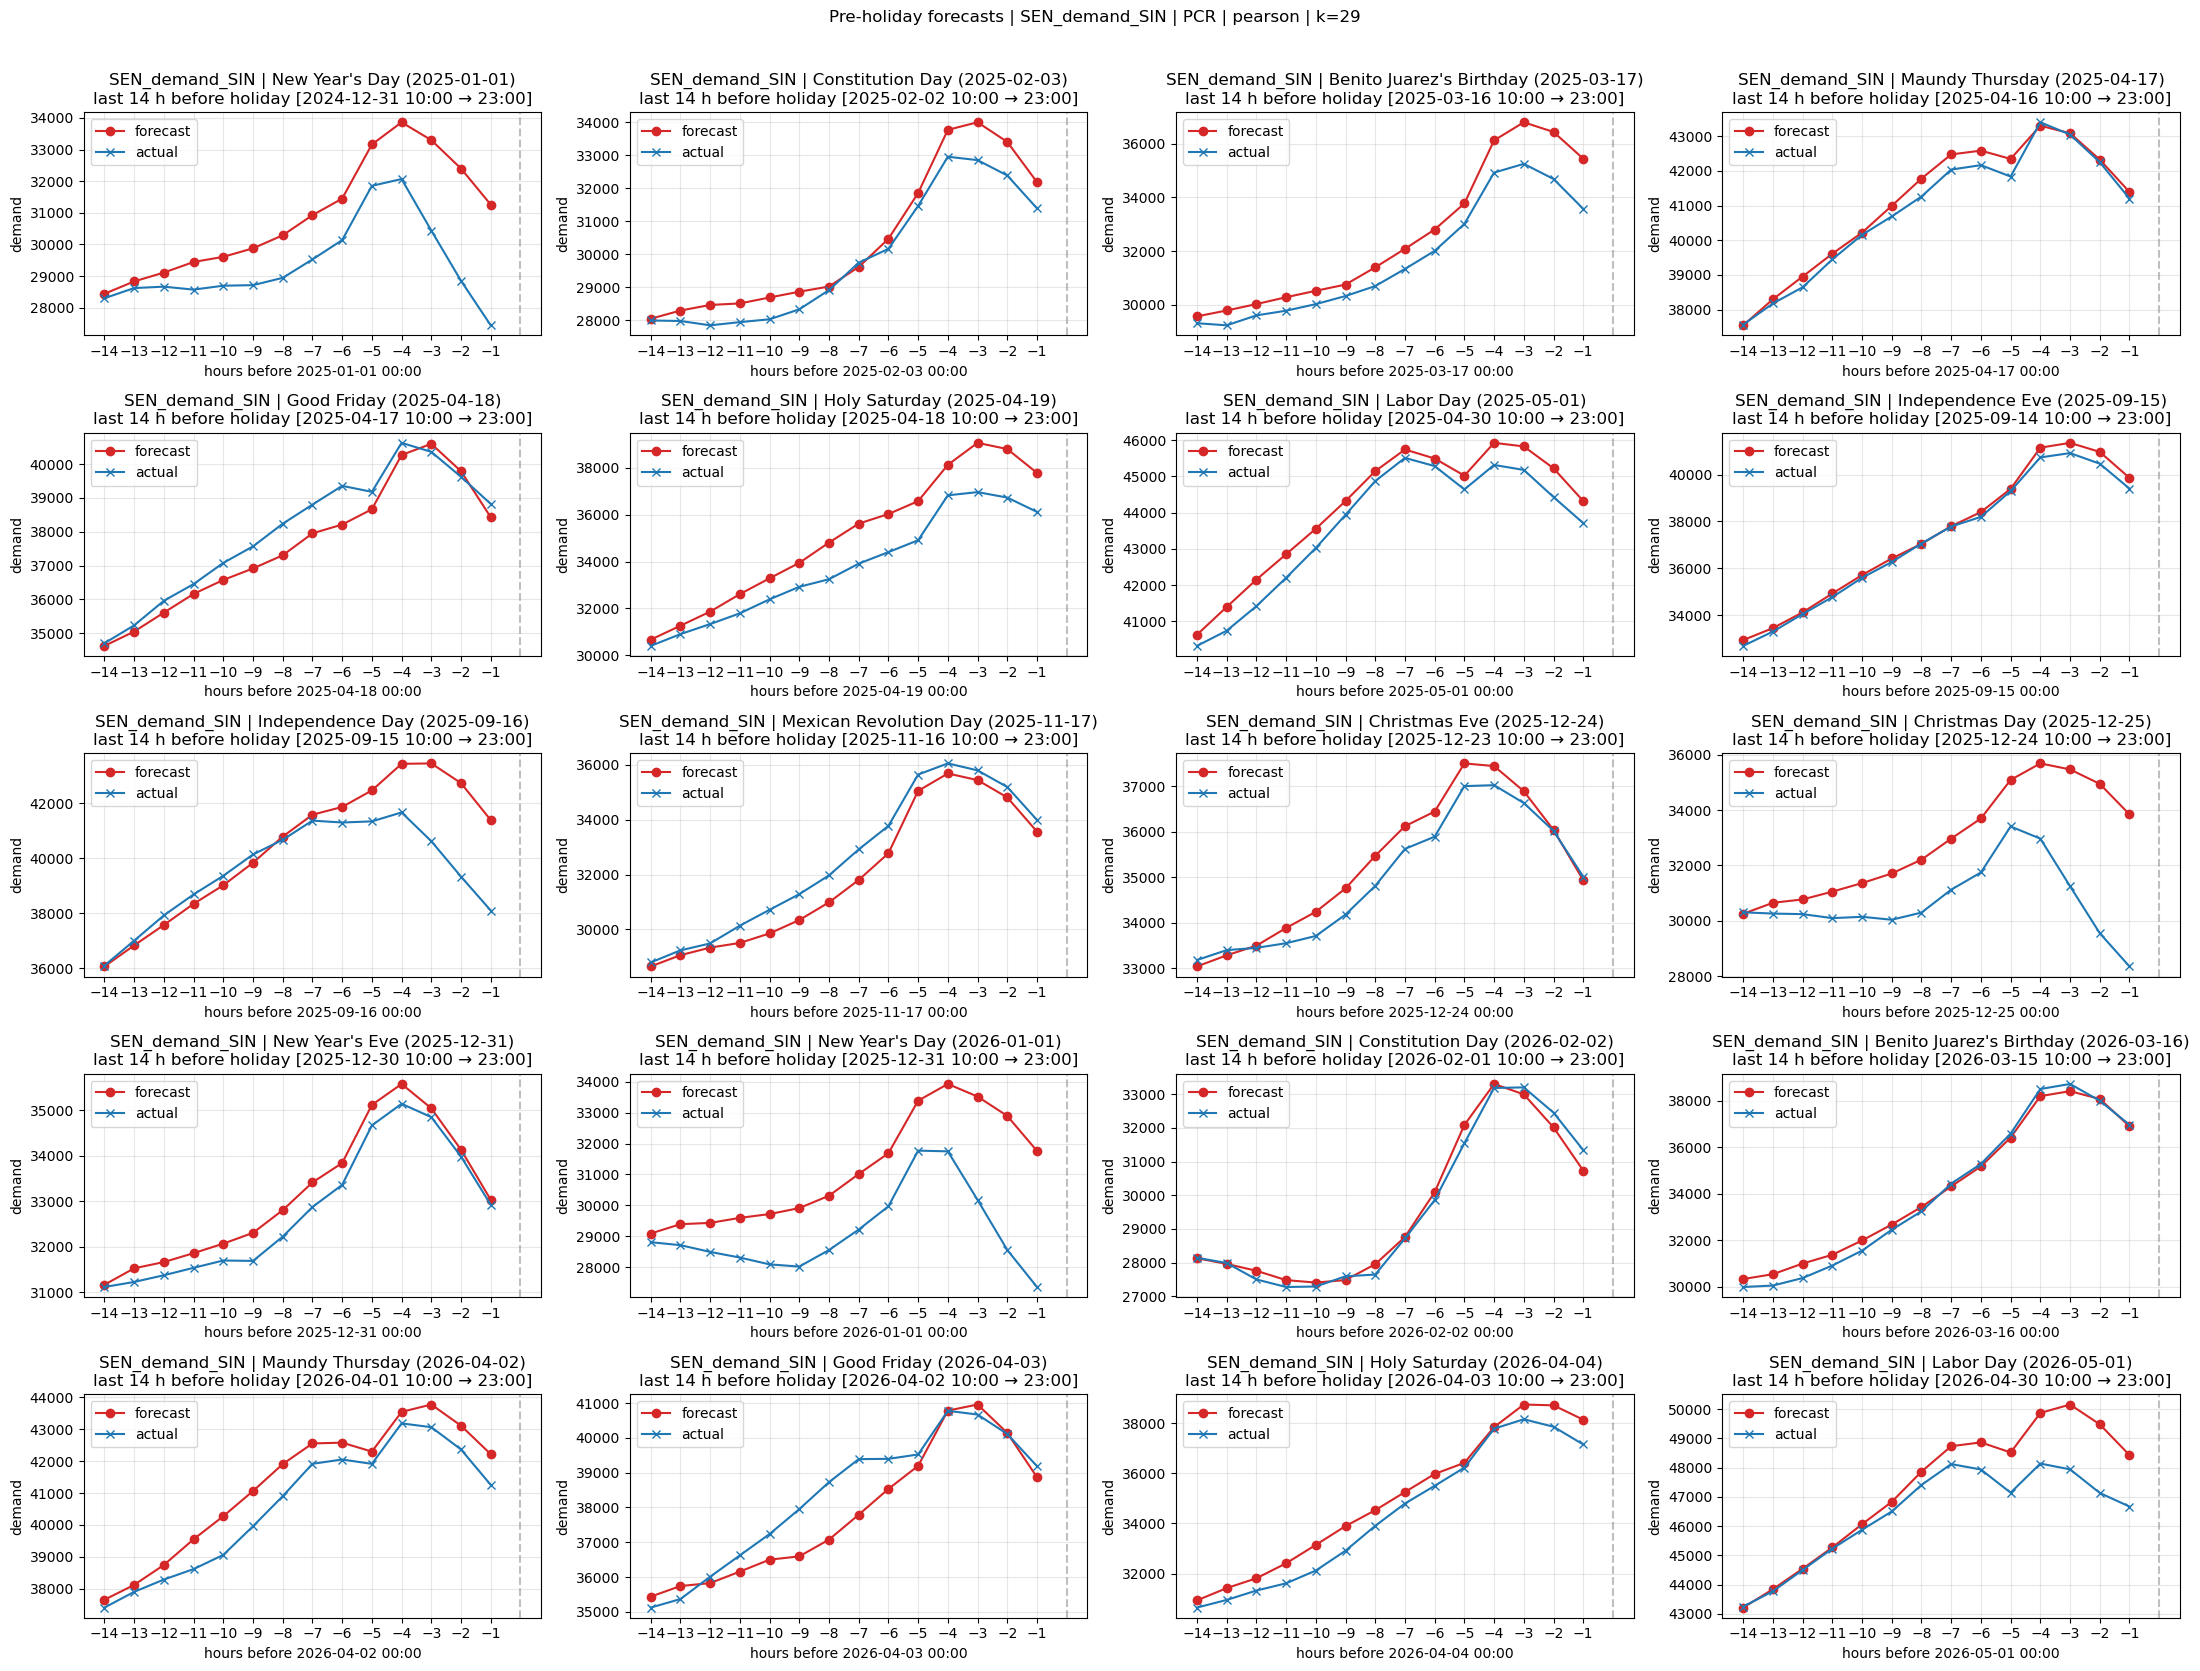

In [17]:
grid_uid = (UNIQUE_IDS or available_ids)[0]
fig, axes = plot_pre_holiday_batch_grid(
    batch_result,
    unique_id=grid_uid,
    title=f'Pre-holiday forecasts | {grid_uid} | {TYPEREG} | {TYPEDIST} | k={K}',
)
plt.show()

## Verify the exported CSV

Reload the new file and compare against the source on the pre-holiday window.

In [18]:
df_out = pd.read_csv(batch_result.output_path, parse_dates=['ds'])
uid_check = (UNIQUE_IDS or available_ids)[0]
target_ts = pd.Timestamp(TARGET_DATE).normalize()
pre_start = target_ts - pd.Timedelta(hours=PREVIOUSLY_W_HOURS)
mask = (df_out['ds'] >= pre_start) & (df_out['ds'] < target_ts)
df_compare = pd.DataFrame({
    'ds': df_out.loc[mask, 'ds'].to_numpy(),
    'source': df_source.loc[mask, uid_check].to_numpy(),
    'overwritten': df_out.loc[mask, uid_check].to_numpy(),
})
df_compare

,ds,source,overwritten
0,2026-04-30 10:00:00,43244.0,43212.0
1,2026-04-30 11:00:00,43772.0,43841.0
2,2026-04-30 12:00:00,44498.0,44541.0
3,2026-04-30 13:00:00,45230.0,45270.0
4,2026-04-30 14:00:00,45874.0,46065.0
5,2026-04-30 15:00:00,46502.0,46830.0
6,2026-04-30 16:00:00,47409.0,47864.0
7,2026-04-30 17:00:00,48122.0,48734.0
8,2026-04-30 18:00:00,47937.0,48864.0
9,2026-04-30 19:00:00,47143.0,48520.0
